# Sentinel-2 Dataset Preparation

This notebook prepares a pair of Sentinel-2 True Color Images of the same geographical tile captured on different dates.

The original `.jp2` files are large, so they are:

1. loaded from Google Drive;
2. inspected;
3. resized while preserving the aspect ratio;
4. saved as PNG files for further keypoint detection and image matching.

In [22]:
!pip install rasterio opencv-python-headless matplotlib -q

In [23]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import rasterio

In [24]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:

drive_root = Path("/content/drive/MyDrive")

all_tci_files = list(drive_root.rglob("*_TCI.jp2"))

print(f"Найдено TCI-файлов: {len(all_tci_files)}\n")

for file_path in all_tci_files:
    print(file_path)

Найдено TCI-файлов: 2

/content/drive/MyDrive/Task2_Sentinel2_Matching data raw/T36UYA_20190606T083601_TCI.jp2
/content/drive/MyDrive/Task2_Sentinel2_Matching data raw/T36UYA_20190909T083559_TCI.jp2


In [33]:
tci_files = sorted(all_tci_files)

if len(tci_files) != 2:
    raise ValueError(
        f"Expected exactly 2 TCI images, but found {len(tci_files)}"
    )

for file_path in tci_files:
    size_mb = file_path.stat().st_size / (1024 ** 2)
    print(f"{file_path.name}: {size_mb:.2f} MB")

T36UYA_20190606T083601_TCI.jp2: 126.62 MB
T36UYA_20190909T083559_TCI.jp2: 128.92 MB


In [34]:
import shutil
from pathlib import Path

PROJECT_DIR = Path("/content/Task2_Sentinel2_Matching")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

local_raw_files = []

for source in tci_files:
    destination = RAW_DIR / source.name
    shutil.copy2(source, destination)

    local_raw_files.append(destination)
    print(f"Copied: {source.name}")

Copied: T36UYA_20190606T083601_TCI.jp2
Copied: T36UYA_20190909T083559_TCI.jp2


In [35]:
list(RAW_DIR.iterdir())

[PosixPath('/content/Task2_Sentinel2_Matching/data/raw/data'),
 PosixPath('/content/Task2_Sentinel2_Matching/data/raw/T36UYA_20190909T083559_TCI.jp2'),
 PosixPath('/content/Task2_Sentinel2_Matching/data/raw/T36UYA_20190606T083601_TCI.jp2')]

In [36]:
import rasterio

for image_path in local_raw_files:
    with rasterio.open(image_path) as src:
        print("=" * 60)
        print(image_path.name)
        print("Width :", src.width)
        print("Height:", src.height)
        print("Bands :", src.count)

T36UYA_20190606T083601_TCI.jp2
Width : 10980
Height: 10980
Bands : 3
T36UYA_20190909T083559_TCI.jp2
Width : 10980
Height: 10980
Bands : 3


In [37]:

def read_rgb_image(image_path):
    """
    Read a Sentinel-2 TCI image as an RGB NumPy array.
    """
    with rasterio.open(image_path) as src:
        image = src.read()

    image = np.transpose(image, (1, 2, 0))

    if image.shape[2] != 3:
        raise ValueError(
            f"Expected 3 channels, but got shape {image.shape}"
        )

    return image

In [38]:
image_1 = read_rgb_image(local_raw_files[0])
image_2 = read_rgb_image(local_raw_files[1])

print("Image 1:", image_1.shape, image_1.dtype)
print("Image 2:", image_2.shape, image_2.dtype)

Image 1: (10980, 10980, 3) uint8
Image 2: (10980, 10980, 3) uint8


In [39]:
import cv2
import matplotlib.pyplot as plt


def resize_for_preview(image, max_side=1000):
    height, width = image.shape[:2]
    scale = min(max_side / max(height, width), 1.0)

    new_size = (
        int(round(width * scale)),
        int(round(height * scale))
    )

    return cv2.resize(
        image,
        new_size,
        interpolation=cv2.INTER_AREA
    )

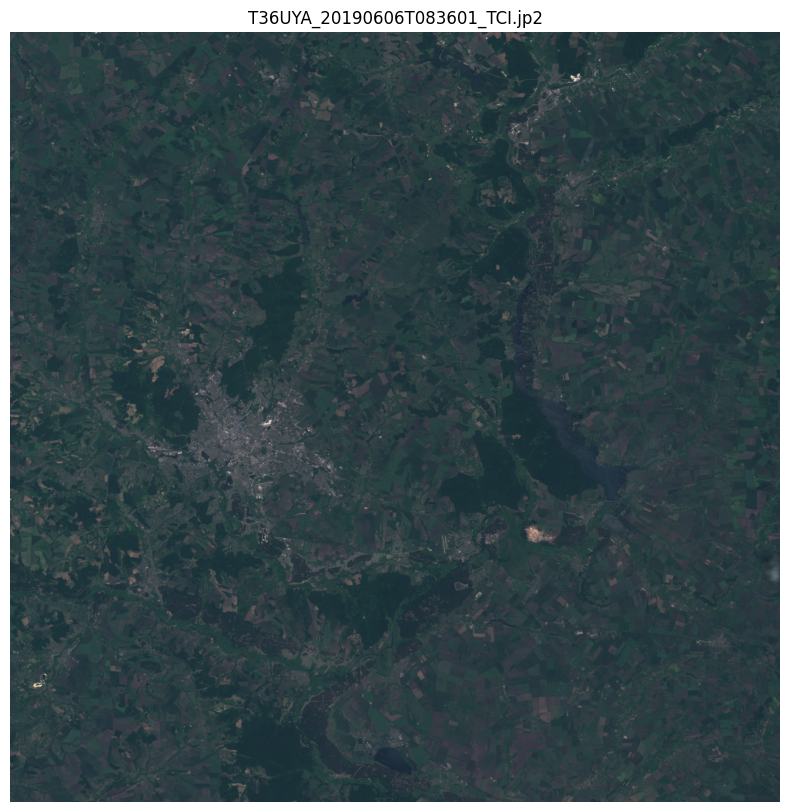

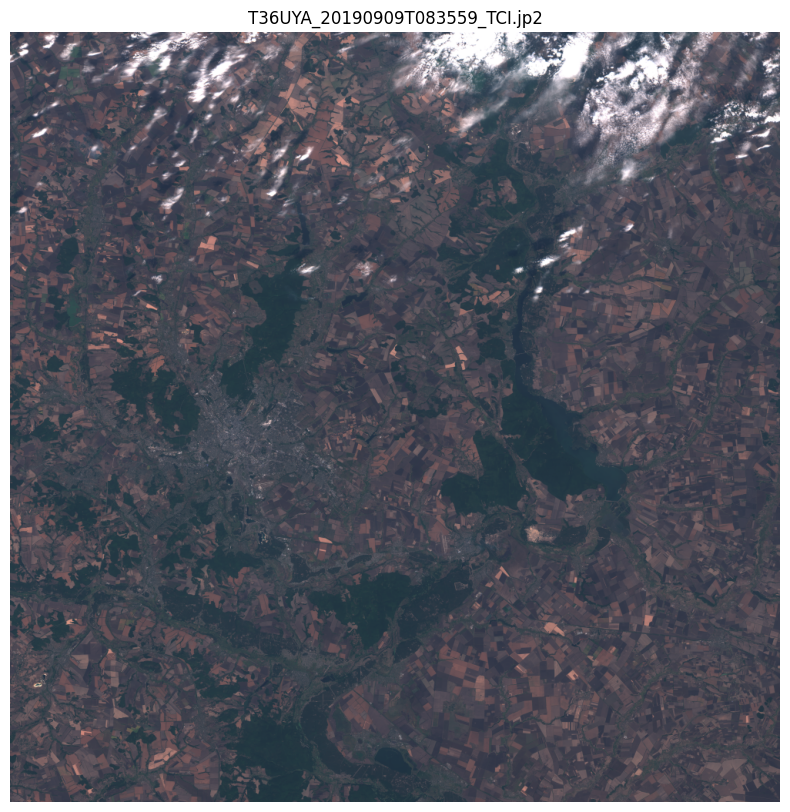

In [40]:
preview_1 = resize_for_preview(image_1)
preview_2 = resize_for_preview(image_2)

plt.figure(figsize=(10, 10))
plt.imshow(preview_1)
plt.title(local_raw_files[0].name)
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(preview_2)
plt.title(local_raw_files[1].name)
plt.axis("off")
plt.show()

In [41]:
def resize_preserving_aspect_ratio(image, max_side=2000):
    """
    Resize an image while preserving its aspect ratio.
    """
    height, width = image.shape[:2]
    scale = min(max_side / max(height, width), 1.0)

    new_width = int(round(width * scale))
    new_height = int(round(height * scale))

    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )

    return resized

In [42]:
processed_image_1 = resize_preserving_aspect_ratio(
    image_1,
    max_side=2000
)

processed_image_2 = resize_preserving_aspect_ratio(
    image_2,
    max_side=2000
)

print("Processed image 1:", processed_image_1.shape)
print("Processed image 2:", processed_image_2.shape)

Processed image 1: (2000, 2000, 3)
Processed image 2: (2000, 2000, 3)


In [43]:
output_path_1 = (
    PROCESSED_DIR / "T36UYA_20190606_rgb_2000.png"
)

output_path_2 = (
    PROCESSED_DIR / "T36UYA_20190909_rgb_2000.png"
)

success_1 = cv2.imwrite(
    str(output_path_1),
    cv2.cvtColor(processed_image_1, cv2.COLOR_RGB2BGR)
)

success_2 = cv2.imwrite(
    str(output_path_2),
    cv2.cvtColor(processed_image_2, cv2.COLOR_RGB2BGR)
)

print("Image 1 saved:", success_1, output_path_1)
print("Image 2 saved:", success_2, output_path_2)

Image 1 saved: True /content/Task2_Sentinel2_Matching/data/processed/T36UYA_20190606_rgb_2000.png
Image 2 saved: True /content/Task2_Sentinel2_Matching/data/processed/T36UYA_20190909_rgb_2000.png


In [44]:
processed_files = sorted(PROCESSED_DIR.glob("*.png"))

for file_path in processed_files:
    size_mb = file_path.stat().st_size / (1024 ** 2)
    print(f"{file_path.name}: {size_mb:.2f} MB")

T36UYA_20190606_rgb_2000.png: 5.31 MB
T36UYA_20190909_rgb_2000.png: 5.86 MB
